## APPLIED STATISTICS

### Turma 16DTSR


#### Trabalho prático usando o Python
### Sorteio de amostra probabilística e cálculo do Intervalo de confiança de 95%


In [ ]:
# Importar as bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


### Contexto dos dados

A gerente da área de Marketing Relacionamento da empresa XYZ tem observado, nas últimas campanhas,
um aumento no número de clientes não contatados. Uma das estratégias para melhorar esse quadro é a
utilização de outros canais de relacionamento. A gerente deseja testar os canais de relacionamento
em uma amostra de tamanho igual a 40.



#### Dicionário de variáveis:

#### Sexo: 2=Masculino;4=Feminino

#### Idade: Idade

#### Cor_pele:0=missing; 2=Branca; 4=Preta; 6=Amarela; 8 = Parda

#### Anos_estudo: Anos de estudo

#### Telefone móvel:2=Sim; 4=Não ( lembrar que esta é a informação que queremos pesquisar!!!!)

# Importar o arquivo de dados

In [ ]:
# Importar o arquivo Arq_Marketing Relacionamento da empresa XYZ.csv

df = pd.read_csv('Data/Arq_Marketing Relacionamento da empresa XYZ.csv', sep=',')

In [ ]:
# visualizando alguns dados
df.head()

In [ ]:
# visualizando formatos das variáveis
df.info()

In [ ]:
# mudar o formato da variável number para string
df['Sexo'] = df['Sexo'].astype(str)
df['Cor_pele'] = df['Cor_pele'].astype(str)
df['Telefone_movel'] = df['Telefone_movel'].astype(str)

In [ ]:
# visualizando formatos das variáveis
df.info()

# Tabela de Frequência da População

In [ ]:
# table(Sexo)
sexo =pd.pivot_table(df, index='Sexo', values='ID', aggfunc=np.count_nonzero)

In [ ]:
sexo['%'] = (pd.pivot_table(df, index='Sexo', values='ID', aggfunc=np.count_nonzero))/df['ID'].count()*100
sexo

In [ ]:
# table(Cor_pele)
corpele =pd.pivot_table(df, index='Cor_pele', values='ID', aggfunc=np.count_nonzero)


In [ ]:
corpele ['%'] = (pd.pivot_table(df, index='Cor_pele', values='ID', aggfunc=np.count_nonzero))/df['ID'].count()*100
corpele

#### Medidas resumo da Idade e Anos de estudo da População

In [ ]:
df.describe()

In [ ]:
# Histograma da variável idade
plt.hist(df['idade'], bins=5)
plt.ylabel('Frequência')
plt.xlabel('idade')
plt.title('Histograma idade');

In [ ]:
# Histograma da variável Anos_estudo
plt.hist(df['Anos_estudo'], bins=5)
plt.ylabel('Frequência')
plt.xlabel('Anos_estudo')
plt.title('Histograma Anos_estudo');

# Sorteio da amostra probabilística

In [ ]:
#amostra probabilística simples sem repetição com 40 unidades

# df_sample = df.sample(40)

df_sample = df.sample(40, random_state = 17)

In [ ]:
# visualizando formatos das variáveis da amostra
df_sample.info()

In [ ]:
df_sample

### Medidas resumo da Idade e Anos de estudo da Amostra

In [ ]:
df.describe().round(2)

In [ ]:
df_sample.describe().round(2)

### Tabela de Frequência da Amostra

In [ ]:
# table(sexo)
sexo_ams =pd.pivot_table(df_sample, index='Sexo', values='ID', aggfunc=np.count_nonzero)

In [ ]:
sexo_ams['%'] = (pd.pivot_table(df_sample, index='Sexo', values='ID', aggfunc=np.count_nonzero))/df_sample['ID'].count()*100
sexo_ams

### Será que podemos aceitar esta amostra como representativa?

### No caso de uma variável categórica como sexo:  Teste de Proporção

### Ho: p=proporção de sexo masculino da população= 47.400612
### H1: p# 47.400612
### alfa=0.05 pontocritico:1.96
### teste t = (pestimado- p) /SE
### SE = SQRT((p*(1-p))/n)

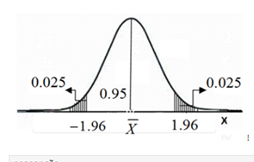


In [ ]:
variando p  proporção

p=0.10  q=(1-p)=0.90
p=0.20  q=(1-p)=0.80
p=0.30  q=(1-p)=0.70
p=0.40  q=(1-p)=0.60
p=0.50  q=(1-p)=0.50
p=0.60  q=(1-p)=0.40

In [ ]:
p=0.474
n=40
pestimado=0.45
SE = (p*(1-p)/n)**(0.5)
t=(pestimado-p)/SE
t

Veja que o valor da estatistica t, o valor esta na área de aceitação, ou na área de rejeição?

In [ ]:
O valor de p é a probabilidade de obter uma estatística de teste tão extrema quanto a que observamos,
assumindo que a hipótese nula é verdadeira.

P(t∣>∣-0.304∣)

Lembrando!!!!!!!!!!!!!!!!!!

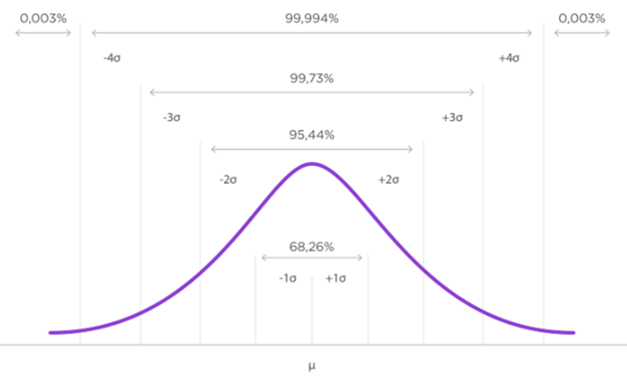

#### Teste de médias Variáveis Quantitativas

In [ ]:

from scipy import stats

# Teste de média
# A função ttest_1samp() retorna um valor de estatística t e um valor p.
# Teste de média
# Ho: mediaIdade_amostra '=' mediaIdade_população
# H1: mediaIdade_amostra '#' mediaIdade_população


In [ ]:
# testando a media de idade da amostra com a média da idade da população
print('t-statistic = %6.3f pvalue = %6.4f' %  stats.ttest_1samp(df_sample['idade'], popmean=np.mean(df['idade'])))

Como o valor p para o problema em questão é superior a 0,05, que é o valor alfa, aceitamos a hipótese nula

==> A idade da amostra vem da mesma população do estudo com 95% de confiança

In [ ]:
# testando a media de anos de estudo da amostra com a média de anos de estudo da população

print('t-statistic = %6.3f pvalue = %6.4f' %  stats.ttest_1samp(df_sample['Anos_estudo'], popmean=np.mean(df['Anos_estudo'])))


Como o valor p para o problema em questão é superior a 0,05, que é o valor alfa, aceitamos a hipótese nula

==> A variável Anos de estudo da amostra vem da mesma população do estudo com 95% de confiança

### O que fazemos quando o teste é rejeitado?

### Voltando ao objetivo da Pesquisa: Medir a quantidade de pessoas com telefone celular.

In [ ]:
# table(tem telefone celular)

frequencia = df_sample['Telefone_movel'].value_counts()
percentual = df_sample['Telefone_movel'].value_counts(normalize = True)*100
dist_freq_amostra = pd.DataFrame({'Frequência': frequencia, 'Porcentagem(%)': percentual})
dist_freq_amostra

#### Esses resultados foram obtidos através de uma amostra aleatória selecionada
#### Mas................... Se tivessemos escolhido outra semente aleatória e tivessemos extraído outra amostra

    Os resultados seriam os mesmos ou poderiam variar?

    Erro padrão: é a medida de variação de uma média amostral em relação á média populacional
                 é uma medida que ajuda a verificar a confiabilidade Média amostral calculada
                 erro padrão = desvio padrão dividido pela raiz quadrada do tamanho da amostra(n)

    Através do erro padrão, podemos calcular o intervalo de confiança da média populacional a partir da média amostral calculada
                 

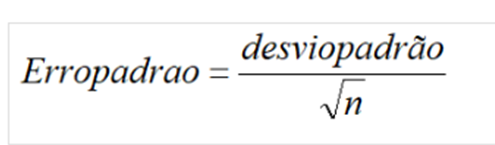

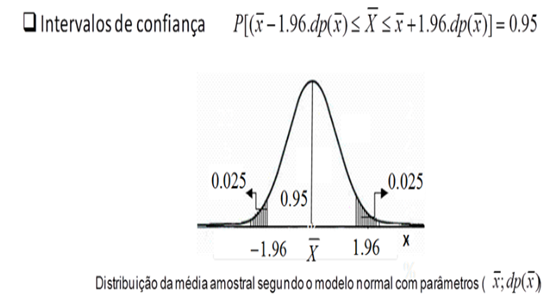

### Cálculo do Intervalo de Confiança de 95% para proporção

#### Limite inferior = p - 1.96*sqrt(p*q)
#### Limite superior = p + 1.96*sqrt(p*q)

#### nível de confiança de 95% = 1.96
#### p=proporção de usuários de telefone móvel
#### q= 1-p = proporção de usuários sem telefone móvel

### Cálculo da proporção de clientes com telefone

### Alterar o número de clientes com telefone móvel (k)
### prop_tel=k/40


In [ ]:
telefone_ams =pd.pivot_table(df_sample, index='Telefone_movel', values='ID', aggfunc=np.count_nonzero)
telefone_ams['%'] = (pd.pivot_table(df_sample, index='Telefone_movel', values='ID', aggfunc=np.count_nonzero))/df_sample['ID'].count()*100
telefone_ams

In [ ]:
# p=proporção de usuários de telefone móvel
# q= 1-p = proporção de usuários sem telefone móvel
# nível de confiança de 95% = 1.96

# Erro padrão da proporção
p=0.80
q= 1-p
erro_padrao= p*q/np.sqrt(len(df_sample))
erro_padrao

In [ ]:
import math as math

# Cálculo do Erro padrão

# 1 passo: criar a variável dummy se tem telefone móvel
df_sample.loc[(df_sample.Telefone_movel == "2"), 'amostra_clientes_com_telefone']=1

# 2 passo: somar as pessoas com telefone móvel
amostra_clientes_com_telefone = df_sample['amostra_clientes_com_telefone'].sum()

print('total com telefone {}'.format(amostra_clientes_com_telefone))

# 3 passo: tamanho da amostra
tamanho_amostra = len(df_sample)

print('tamanho da amostra {}'.format(tamanho_amostra))

# 4 passo: calcular a proporcao de clientes com telefone
prop_telefone = amostra_clientes_com_telefone/tamanho_amostra
prop_telefone
print('prop_telefone {}'.format(prop_telefone))
# 5 passo: calcular o erro padrão
erro_padrao =((prop_telefone*(1-prop_telefone))/(tamanho_amostra)**(1/2))
print('erro_padrao {}'.format(erro_padrao))

In [ ]:
#Limite inferior do intercalo de confiança
Limite_inferior = p - 1.96*erro_padrao
Limite_inferior

In [ ]:
#Limite superior do intervalo de confiança
Limite_superior = p + 1.96*erro_padrao
Limite_superior

In [ ]:
# Intervalo de Confiança da variável penetração de celular na população
print (' IC da Celular', '\n Penetração=:', p,'\n Limite Inferior:', Limite_inferior  ,'\n Limite Superior:', Limite_superior)

### E qual o % telefone móvel da população?

In [ ]:
df.Telefone_movel.value_counts(normalize=True)

### E se tivessemos usado uma amostra para estimar uma média, por exemplo idade média dos clientes

In [ ]:
#Cálculo do IC da média da variável idade
IdadeMédia=np.mean(df_sample['idade'])
IdadeMédia

In [ ]:
from scipy.stats import norm
alfa=0.05
n=40
z=norm.ppf(1-alfa/2,0,1)
z


In [ ]:
IdadeStd= np.std(df_sample['idade'])/(n**0.5)
IdadeStd

In [ ]:
Xinf=IdadeMédia - z*IdadeStd
Xinf

In [ ]:
Xsup=IdadeMédia + z*IdadeStd
Xsup

In [ ]:
# Intervalo de Confiança da variável média de idade
print (' IC da Idade', '\n Idade média=:', IdadeMédia,'\n Limite Inferior:', Xinf  ,'\n Limite Superior:', Xsup)



In [ ]:
# vamos dar uma olhadinha na média da população

IdadeMédia=np.mean(df['idade'])
IdadeMédia